# 문제 정의 : 주말에는 선릉역보다 뚝섬역이 더 붐빌까?

In [1]:
# 필요한 라이브러리를 불러옵니다.

import os # 폴더/파일을 관리하는 os 라이브러리
import pandas as pd
# 시각화를 위한 설정하기
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive


# Google Drive 마운트
drive.mount('/content/drive')

# 파일이 저장된 Google Drive 경로 설정
drive_dir_path = '/content/drive/MyDrive/AI+X/'

# 해당 경로의 파일 목록 확인
files = os.listdir(drive_dir_path)

raw = pd.read_csv('/content/drive/MyDrive/AI+X/subway_raw.csv')
display(raw)

Mounted at /content/drive


,사용일자,요일,노선명,역명,승차총승객수,하차총승객수,승하차총승객수,연월,월일,등록일자
0,2019-02-01,금,6호선,이태원,15786,21324,37110,Feb-19,02월 01일,20190204
1,2019-02-01,금,6호선,한강진,9085,10665,19750,Feb-19,02월 01일,20190204
2,2019-02-01,금,6호선,버티고개,2660,2486,5146,Feb-19,02월 01일,20190204
3,2019-02-01,금,3호선,약수,4245,4396,8641,Feb-19,02월 01일,20190204
4,2019-02-01,금,5호선,청구,4236,4612,8848,Feb-19,02월 01일,20190204
...,...,...,...,...,...,...,...,...,...,...
107023,2019-04-30,화,1호선,종로5가,32828,33182,66010,Apr-19,04월 30일,20190503
107024,2019-04-30,화,3호선,종로3가,37628,35721,73349,Apr-19,04월 30일,20190503
107025,2019-04-30,화,1호선,종각,51823,50610,102433,Apr-19,04월 30일,20190503
107026,2019-04-30,화,2호선,시청,32485,32917,65402,Apr-19,04월 30일,20190503


## 가설 설정

+ 귀무가설: 주말에 선릉역과 뚝섬역의 평균 이용객 수에는 차이가 없거나, 선릉역이 더 많다.

+ 대립가설: 주말에 뚝섬역의 평균 이용객 수가 선릉역보다 더 많다.

## 데이터 전처리하기

데이터에서 필요한 정보(주말, 선릉역, 뚝섬역 데이터)를 추출하기

In [2]:
# 주말(토, 일) 데이터만 필터링하기
weekend = raw[raw['요일'].isin(['토', '일'])]

# 선릉역, 뚝섬역 데이터만 필터링하기
filtered_data = weekend[weekend['역명'].isin(['선릉', '뚝섬'])]

# 분석에 필요한 역명, 승하차총승객수 선택.
data = filtered_data[['역명', '승하차총승객수']]

# 결과 확인
display(data)
display(data.info())

,역명,승하차총승객수
766,뚝섬,17667
776,선릉,40388
977,선릉,9677
1203,뚝섬,10154
1213,선릉,19255
...,...,...
104688,선릉,65111
104889,선릉,16825
105270,뚝섬,20956
105280,선릉,34003


<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 766 to 105481
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   역명       156 non-null    object
 1   승하차총승객수  156 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.7+ KB


None

## 기술 통계 분석



In [3]:
# 역별 평균, 표준편차
mean_values = data.groupby("역명")["승하차총승객수"].mean()
std_values = data.groupby("역명")["승하차총승객수"].std()

display(mean_values)
display(std_values)
# 표준 편차 차이를 통해서 둘의 분산이 차이점을 가짐을 알 수 있음

# 상세 기술 통계 (count, mean, std, min, 25%, 50%, 75%, max)
desc_stats = data.groupby("역명")["승하차총승객수"].describe()
display(desc_stats)

,승하차총승객수
역명,
뚝섬,23935.269231
선릉,28906.961538


,승하차총승객수
역명,
뚝섬,5920.244282
선릉,20797.556200


,count,mean,std,min,25%,50%,75%,max
역명,,,,,,,,
뚝섬,52.0,23935.269231,5920.244282,10154.0,19251.00,23858.5,27836.50,35506.0
선릉,104.0,28906.961538,20797.556200,4467.0,9443.75,18461.5,35635.25,65992.0


# 통계 검정


+ 주요 확인 사항
    + N > 30 인가? : 선릉 104개, 뚝섬 52개
    + 정규성을 만족하는가?
        + 선릉역이 이상하게 나오는 모습을 보인다.
        + 뚝섬역은 정규분포 모양을하고 있다.

+ 연속형 테이터인가?
    + 승하차총승객수는 연속형 데이터!

+ 집단의 수는 몇개인가?
    + 집단 수: 2개 (주말에서의 - (선릉역 vs 뚝섬역))
    → 따라서 독립표본 t-test 사용

정규성 만족 여부 파악하기

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126435 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


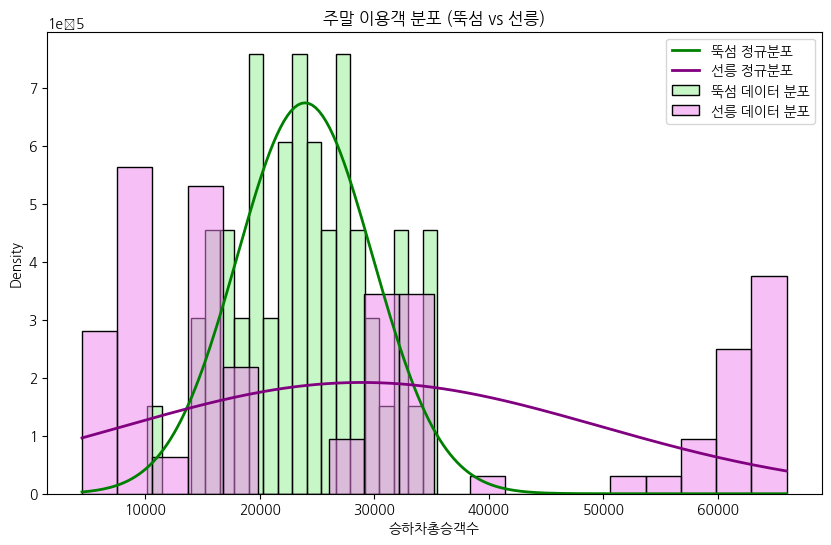

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from matplotlib import font_manager as fm
import matplotlib as mpl

# 정규 분포 확인하기

# 폰트 설정
!sudo apt-get update -qq
!sudo apt-get install fonts-nanum -qq

fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")

mpl.rcParams['font.family'] = 'NanumGothic'

# 데이터 추출
seolleung = data[data['역명'] == '선릉']['승하차총승객수']
ttukseom = data[data['역명'] == '뚝섬']['승하차총승객수']

# 평균과 표준편차
mu_s, sigma_s = seolleung.mean(), seolleung.std()
mu_t, sigma_t = ttukseom.mean(), ttukseom.std()

# X축 범위 (두 집단 합쳐서 최소~최대)
x = np.linspace(min(seolleung.min(), ttukseom.min()),
                max(seolleung.max(), ttukseom.max()), 200)

plt.figure(figsize=(10,6))

# 뚝섬
sns.histplot(ttukseom, bins=20, kde=False, stat="density",
             color="lightgreen", alpha=0.5, label="뚝섬 데이터 분포")
plt.plot(x, stats.norm.pdf(x, mu_t, sigma_t), color="green", linewidth=2, label="뚝섬 정규분포")

# 선릉
sns.histplot(seolleung, bins=20, kde=False, stat="density",
             color="violet", alpha=0.5, label="선릉 데이터 분포")
plt.plot(x, stats.norm.pdf(x, mu_s, sigma_s), color="purple", linewidth=2, label="선릉 정규분포")

plt.title("주말 이용객 분포 (뚝섬 vs 선릉)")
plt.legend()
plt.show()

독립 표본 결과 확인하기

In [19]:
from scipy.stats import ttest_ind

# 독립표본 t-test 결과 얻기
t_result, p_value = ttest_ind(ttukseom, seolleung, equal_var = False) # 분산이 다르더라도 안전하게 평균 차이를 비교하기 위해서 사용, equal_var = False

print("t-test-result:", t_result)
print("p-value :", p_value)
print("p 0.0.5 이하로 평균 차이가 있다(다르다) -> 두 집단이 같은 모집단에서 나온 게 아니라, 승객 수 수준 자체가 다르고 이 차이가 우연이아니라 통계적으로 차이기 있다.")

# 근데 단측 검정이라는 것은 왜 해야할까? -> 지금의 그냥 p_value는"뚝섬과 선릉의 평균이 다르다고 볼 수 있는가" 에 대힌 결과를 의미함
# 그래서 단측 검정이라는 것을 통해서 "뚝섬이 선릉보다 많다”를 확인하기!!!
# 단측 검정 (뚝섬 > 선릉)
if t_result > 0:
    # t값이 양수 → 뚝섬 평균이 더 클 가능성
    p_val_one = p_value / 2
else:
    # t값이 음수 → 선릉 평균이 더 크거나 같음
    p_val_one = 1 - (p_value / 2)

print("p-value_one (뚝섬 > 선릉):", p_val_one)

# 해석
# 양측 검정 p값은 0.0254(t = −2.26)**로 유의수준 0.05보다 작아서
# 두 역의 주말 평균 이용객 수에는 통계적으로 유의한 차이가 있다.
# t값이 음수이므로 평균 크기의 방향은 선릉역 > 뚝섬역
# 초기 가설을 뚝섬역이 선릉역보다 많다” 단측 가설(뚝섬 > 선릉)이였으므로
# 단측 p값은 약 0.987로 0.05 이상이므로 귀무가설을 기각할 수 없음!
# 따라서 초기 가설(주말에 뚝섬 > 선릉)과는 다른 결과가 나왔고
# 주말 평균은 선릉역이 더 크다는 방향의 차이를 p와 t의 결과 값으로 구할 수 있었다,
# -------------------------------------------------------------------------------
# equal_var = True를 했을 경우 나오는 결과
# t-test-result: -1.6875144045661736
# p-value : 0.09352882420289814
# 분산 차이가 커서 고려해야 하는 요소임을 함을 알 수 있음!

t-test-result: -2.261485023455851
p-value : 0.025363632808710904
p 0.0.5 이하로 평균 차이가 있다(다르다) -> 두 집단이 같은 모집단에서 나온 게 아니라, 승객 수 수준 자체가 다르고 이 차이가 우연이아니라 통계적으로 차이기 있다.
p-value_one (뚝섬 > 선릉): 0.9873181835956445


'\n양측 검정 p값은 0.0254(t = −2.26)**로 유의수준 0.05보다 작아서\n두 역의 주말 평균 이용객 수에는 통계적으로 유의한 차이가 있다.\nt값이 음수이므로 평균 크기의 방향은 선릉역 > 뚝섬역 \n초기 가설을 뚝섬역이 선릉역보다 많다” 단측 가설(뚝섬 > 선릉)이였으므로\n단측 p값은 약 0.987로 0.05 이상이므로 귀무가설을 기각할 수 없음!\n따라서 초기 가설(주말에 뚝섬 > 선릉)과는 다른 결과가 나왔고\n주말 평균은 선릉역이 더 크다는 방향의 차이를 p와 t의 결과 값으로 구할 수 있었다,\n-------------------------------------------------------------------------------\nequal_var = True를 했을 경우 나오는 결과 \nt-test-result: -1.6875144045661736\np-value : 0.09352882420289814 \n분산 차이가 커서 고려해야 하는 요소임을 함을 알 수 있음!\n'

/tmp/ipython-input-13830025.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=data, x="역명", y="승하차총승객수", ci=95, palette=["lightgreen", "violet"])
/tmp/ipython-input-13830025.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="역명", y="승하차총승객수", ci=95, palette=["lightgreen", "violet"])


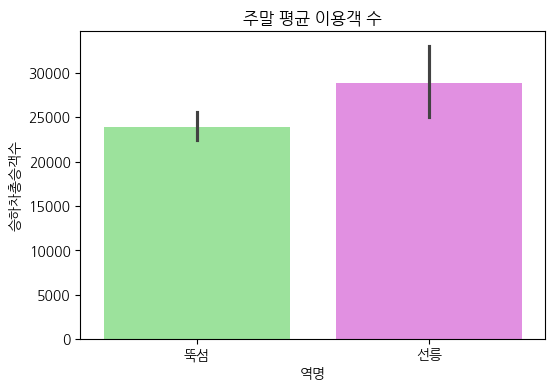

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(data=data, x="역명", y="승하차총승객수", ci=95, palette=["lightgreen", "violet"])
plt.title("주말 평균 이용객 수")
plt.show()

# 막대를 통해서 평균 이용객 수를 확인하면
# 뚝섬보다 선릉의 평균 이용객 수가 더 높게 나타남

# 검정색 선은 95% 신뢰구간을 의미하는데 이 검정 선이 일부 겹치는 경우에는 평균 차이는 보이지만, 아주 확실하다고 보기엔 애매한 수준임을 알 수 있다.
# 그래서 위에서 나온 t,p 값과 함계 해석 하면
# 실제 검정 결과 p-value < 0.05로, 두 집단의 평균 차이는 유의미하다 -> 실제 값이 차이가 있음을 알 수 있다. -> 그러면 어떤 차이?
# p_one = 0.9 > 0.05 => 선릉이 뚝섬보다 더 많다.